# Bird Sound Classification


Using deep learning to classify bird sounds from environmental audio recordings.

Dataset: ESC-50 (Environmental Sound Classification) - 50 classes, 2000 audio clips (5 seconds each).
Focus: Bird-related classes (Crow, Hen, Rooster, etc.)

##Import & Install

In [48]:
!pip install datasets librosa soundfile -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

from datasets import load_dataset

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Resizing
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from IPython.display import Audio

from skimage.transform import resize #for manualy Resizeing Spectograms

##Load Dataset (Use a small subset for Colab)


###1. Use Kaggle
    1.   https://www.kaggle.com/datasets/soumikrakshit/bird-song-data-set
    2.   https://www.kaggle.com/datasets/vinayshanbhag/bird-song-data-set
    3.   BirdCLEF sample
###2. XENO Public Data Set
#### #Example: Download a few bird sounds directly (Great Tit, Sparrow, etc.)
```
urls = {
    "Great_Tit": "https://xeno-canto.org/1080577/download",   # replace with real working links
    "Sparrow": "https://xeno-canto.org/482783/download",
    # Add more species
}
```
###3. Hugging face ESC-50 Dataset
No need for Extenal Links
Dataset: ESC-50 (Environmental Sound Classification) - 50 classes, 2000 audio clips (5 seconds each).
Focus: Bird-related classes (Crow, Hen, Rooster, etc.)


In [2]:
# Load ESC-50 dataset
dataset = load_dataset("ashraq/esc50", split="train")

# Filter only bird-related classes
bird_classes = ['crow', 'hen', 'rooster', 'bird']
bird_data = dataset.filter(lambda x: x['category'] in bird_classes)

print(f"Total bird samples: {len(bird_data)}")
print("Classes:", bird_data.unique('category'))

README.md:   0%|          | 0.00/345 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.61k [00:00<?, ?B/s]

data/train-00000-of-00002-2f1ab7b824ec75(…): reconstructing file:   0%|          |  0.00B /  387MB            

data/train-00000-of-00002-2f1ab7b824ec75(…): downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Total bird samples: 120


Flattening the indices:   0%|          | 0/120 [00:00<?, ? examples/s]

Classes: ['crow', 'hen', 'rooster']


##Audio Preprocessing & Feature Extraction

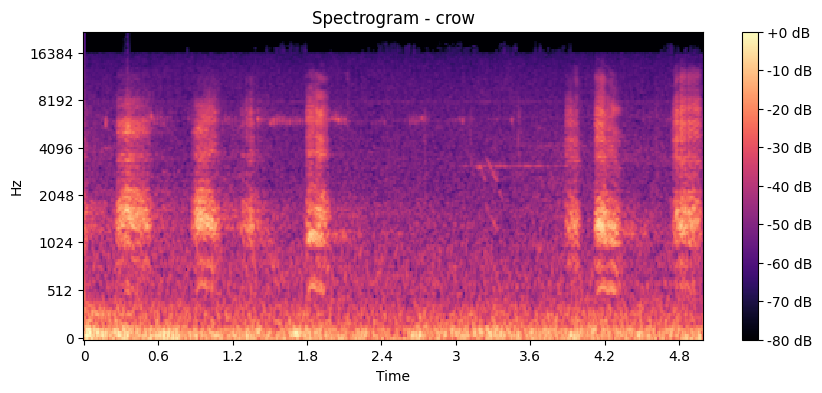

In [16]:
def audio_to_mel_spectrogram(audio, sr=22050):
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec_db

# Convert a few samples for visualization
sample = bird_data[0]
audio = np.array(sample['audio']['array'])
sr = sample['audio']['sampling_rate']

mel_spec = audio_to_mel_spectrogram(audio, sr)

plt.figure(figsize=(10,4))
librosa.display.specshow(mel_spec, x_axis='time', y_axis='mel', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title(f"Spectrogram - {sample['category']}")
plt.show()

display(Audio(audio, rate=sr))

##Dataset Preprocessing for Training

In [35]:
def preprocess_audio(example):
    audio = np.array(example['audio']['array'])
    sr = example['audio']['sampling_rate']
    mel = audio_to_mel_spectrogram(audio, sr)
    mel = mel[..., np.newaxis]  # Add channel dimension
    return {'mel': mel, 'label': example['target']}

# Process dataset
processed = bird_data.map(preprocess_audio)

# Convert to numpy for Keras
X = np.array([item['mel'] for item in processed])
y = np.array([item['label'] for item in processed])

print("Feature shape:", X.shape)
print("Labels shape:", y.shape)

# === FIX: Remap labels to 0,1,2 ===
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("New labels:", np.unique(y_encoded))   # Should be [0, 1, 2]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


Feature shape: (120, 128, 431, 1)
Labels shape: (120,)
New labels: [0 1 2]


##Build Simple CNN Model using Tensorflow for Traing

In [38]:
# Simple CNN
model1 = models.Sequential([
    layers.Input(shape=(128,None,1)),          # None = variable time dimension
    Resizing(128, 128),                        # Resize all to 128 x 128

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),


    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y_encoded)), activation='softmax')
])

model1.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model1.summary()


#print("New shape:", X.shape)  # Should be (N, 128, 216, 1)

# Train
#history = model1.fit(X_train, y_train, epochs=15, validation_split=0.2, batch_size=16)
#plt.plot(history.history['accuracy'])

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_8 (Resizing)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,491 (16.36 MB)

 Trainable params: 4,287,491 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

##2nd CNN model with Reshaping before training

##Reshape Spectrogram Shapes
Your model expects spectrograms of shape (128, 216, 1), but your actual data X has shape (..., 128, 431, 1).
Once Soluution is to change Conv2D Shape is per Input
The width (time dimension) is 431 instead of 216, which breaks the Flatten() → Dense layer.

In [10]:
# Resize all spectrograms to match your model
TARGET_HEIGHT = 128
TARGET_WIDTH = 216

def resize_spectrograms(X):
    X_resized = np.zeros((X.shape[0], TARGET_HEIGHT, TARGET_WIDTH, 1), dtype=np.float32)
    for i in range(X.shape[0]):
        # Resize and keep channel
        resized = resize(X[i, :, :, 0], (TARGET_HEIGHT, TARGET_WIDTH), mode='reflect', anti_aliasing=True)
        X_resized[i, :, :, 0] = resized
    return X_resized

In [39]:
# Simple CNN
model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 216, 1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y_encoded)), activation='softmax')
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model2.summary()

# Apply resize Before Runing Training
#X = resize_spectrograms(X)   # Run this before training

#print("New shape:", X.shape)  # Should be (N, 128, 216, 1)

# Train
#history = model2.fit(X_train, y_train, epochs=15, validation_split=0.2, batch_size=16)
#plt.plot(history.history['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)              │ (None, 126, 214, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 63, 107, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 61, 105, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 30, 52, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 99840)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │    12,779,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,798,851 (48.82 MB)

 Trainable params: 12,798,851 (48.82 MB)

 Non-trainable params: 0 (0.00 B)

#Train the Model with Early Stoping for the best weights

In [43]:
# ==========================
# Train the Model
# ==========================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model1.fit(   # use model1 or model2
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,                  #in case you want to use taining data for validation
    #validation_data=(X_test, y_test),     #in case you want to use early split test data for validation)
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9211 - loss: 0.1514 - val_accuracy: 0.6500 - val_loss: 0.5451
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 840ms/step - accuracy: 0.9605 - loss: 0.1566 - val_accuracy: 0.8000 - val_loss: 0.2888
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 797ms/step - accuracy: 1.0000 - loss: 0.0551 - val_accuracy: 0.8500 - val_loss: 0.2312
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 937ms/step - accuracy: 0.9737 - loss: 0.0871 - val_accuracy: 0.7000 - val_loss: 0.7951
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 539ms/step - accuracy: 0.9868 - loss: 0.0816 - val_accuracy: 0.7000 - val_loss: 0.5426
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 515ms/step - accuracy: 1.0000 - loss: 0.0458 - val_accuracy: 0.8500 - val_loss: 0.2318
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 779ms/step - accuracy: 0.9737 - loss: 0.0782 - val_accuracy: 0.7500 - val_loss: 0.4976
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 669ms/step - accuracy: 1.0000 - loss: 0.0274 - val_accuracy: 0.8500 - val_loss: 0.

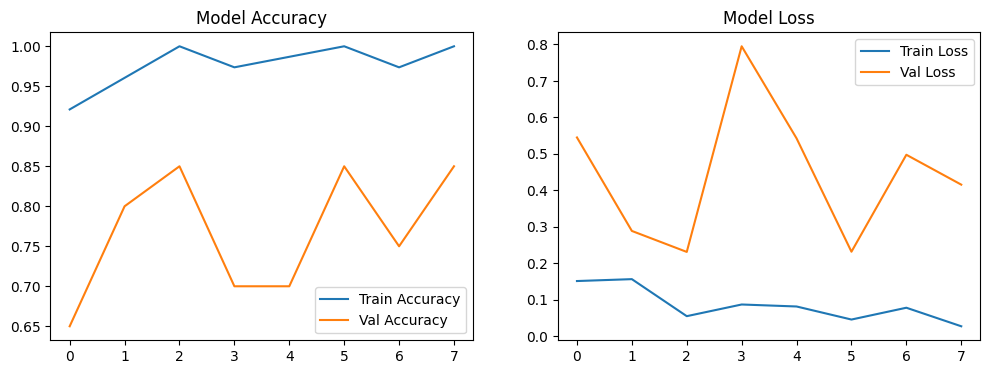

In [44]:
# ==========================
# Plot Training History
# ==========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

##Test / Evaluate the selected Models


Validation Accuracy: 0.9167 (91.67%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.78      0.88         9
           6       0.89      1.00      0.94         8
           9       0.88      1.00      0.93         7

    accuracy                           0.92        24
   macro avg       0.92      0.93      0.92        24
weighted avg       0.93      0.92      0.91        24



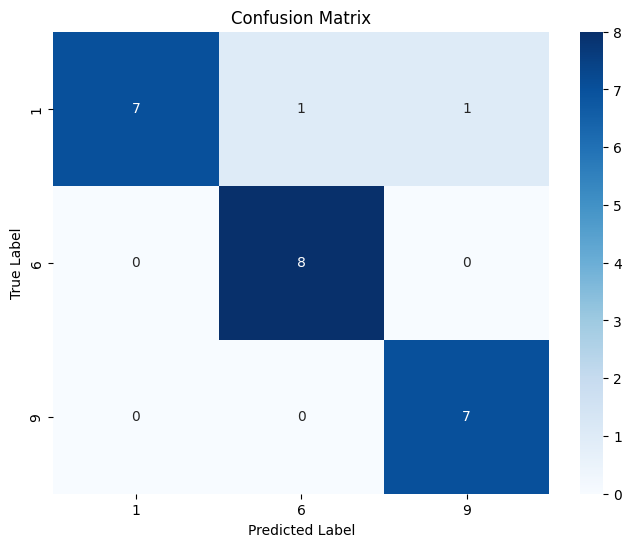

In [50]:
# ==========================
# Test / Evaluate the Model
# ==========================
# Evaluate on validation/Test set
val_loss, val_acc = model1.evaluate(X_test, y_test, verbose=0)  # use model1 or model2
print(f"\nValidation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

# Predictions
y_pred = model1.predict(X_test) # use model1 or model2
y_pred_classes = np.argmax(y_pred, axis=1)

# Fix: Create class_names safely from encoding
class_names = [str(name) for name in label_encoder.classes_]

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes,
                          target_names=class_names)) # label_encoder.classes_

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,                                 #label_encoder.classes_
            yticklabels=class_names)                     #label_encoder.classes_
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ==========================
# Save Model (Optional)
# ==========================
#model.save("bird_sound_cnn_model.h5")
#print("Model saved as 'bird_sound_cnn_model.h5'")

### Common Issues & Solutions

| # | Issue | Cause | Fix |
|---|-------|-------|-----|
| 1 | **Shape Mismatch** | Spectrogram dimensions don't match model input | Use `resize()` or change `input_shape=(128, 128, 1)` |
| 2 | **Label Out of Range** | Original labels like 6, 9, 14 used | `y_encoded = LabelEncoder().fit_transform(y)` |
| 3 | **TypeError in classification_report** | Integer class names | `class_names = [str(name) for name in label_encoder.classes_]` |
| 4 | **Overfitting** | Small dataset (~120 samples) | Add `Dropout`, `BatchNormalization`, EarlyStopping, and augmentation |
| 5 | **class_names not defined** | Variable not created before use | Define `class_names` right after prediction |

## Key Learnings

- Audio classification requires converting sound into images (spectrograms) for CNNs.
- Mel Spectrograms work better than raw waveforms for bird sounds.
- Converted audio to Mel Spectrograms for CNN input

- Fixed input shape issues using fixed resizing (128x128)

- Used padding='same' to maintain dimensions

- Learned importance of data augmentation for small audio datasets
- Small datasets (like bird subset of ESC-50) benefit greatly from data augmentation.
- Transfer learning (EfficientNet, YAMNet, or BirdNET) would give much better results than training from scratch.
- Real-world bird identification is challenging due to background noise and overlapping calls.
- This project strengthened my understanding of audio signal processing and specialized computer vision for sound.

**Next Steps**:
- Try BirdNET embeddings, add more species, and deploy as a web app.
- XENO Data EDA and Classification
- Try data augmentation + pre-trained models.